In [31]:
import datacube
import cartopy
import pandas as pd
import numpy as np
import xarray as xr


import sys
sys.path.insert(1, "../Tools/")
from dea_tools.plotting import display_map, xr_animation, rgb
from dea_tools.dask import create_local_dask_cluster

In [2]:
dc = datacube.Datacube(app="water difference 2023-2024 example TCP")

In [3]:
create_local_dask_cluster()

/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35221 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/35221/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/35221/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36261,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/35221/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:35337,Total threads: 2
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/34871/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:45459,


2025-04-07 06:00:28,857 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'dataset-77353e6997544d91acf32790314ca260' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x7ff627a35a20>, (Dataset <id=77353e69-9754-4d91-acf3-2790314ca260 product=ga_ls_tc_pc_cyear_3 location=s3://dea-public-data/derivative/ga_ls_tc_pc_cyear_3/2-0-0/x47/y53/2024--P1Y/ga_ls_tc_pc_cyear_3_x47y53_2024--P1Y_final.stac-item.json>,), {})
new run_spec: (<function execute_task at 0x7ff627a35a20>, (Dataset <id=77353e69-9754-4d91-acf3-2790314ca260 product=ga_ls_tc_pc_cyear_3 location=s3://dea-public-data/der

In [26]:
lat = -17.26250
lon = 130.75800

lat_buffer = 0.5
lon_buffer = 0.5


lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)


start_year = "2023"
end_year = "2024"

In [27]:
display_map(lon_range, lat_range)

In [24]:
query = {
    "x": lon_range,
    "y": lat_range,
    "resolution": (-90, 90),
    "time": (start_year, end_year),
    "dask_chunks": {"time": 1, "x": 1024, "y": 1024}
}

product = "ga_ls_tc_pc_cyear_3"

In [25]:
measurements = dc.list_measurements()
measurements.loc[product]

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
wet_pc_10,wet_pc_10,int16,percent,-9999,NaN,NaN
wet_pc_50,wet_pc_50,int16,percent,-9999,NaN,NaN
wet_pc_90,wet_pc_90,int16,percent,-9999,NaN,NaN
green_pc_10,green_pc_10,int16,percent,-9999,NaN,NaN
green_pc_50,green_pc_50,int16,percent,-9999,NaN,NaN
green_pc_90,green_pc_90,int16,percent,-9999,NaN,NaN
bright_pc_10,bright_pc_10,int16,percent,-9999,NaN,NaN
bright_pc_50,bright_pc_50,int16,percent,-9999,NaN,NaN
bright_pc_90,bright_pc_90,int16,percent,-9999,NaN,NaN


In [28]:
ds = dc.load(
    product=product,
    measurements=["green_pc_90"],
    **query
)

In [29]:
ds

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 2, y: 1240, x: 1206)
Coordinates:
  * time         (time) datetime64[ns] 16B 2023-07-02T11:59:59.999999 2024-07...
  * y            (y) float64 10kB -1.708e+06 -1.708e+06 ... -1.82e+06 -1.82e+06
  * x            (x) float64 10kB 1.134e+05 1.135e+05 ... 2.218e+05 2.219e+05
    spatial_ref  int32 4B 3577
Data variables:
    green_pc_90  (time, y, x) int16 6MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

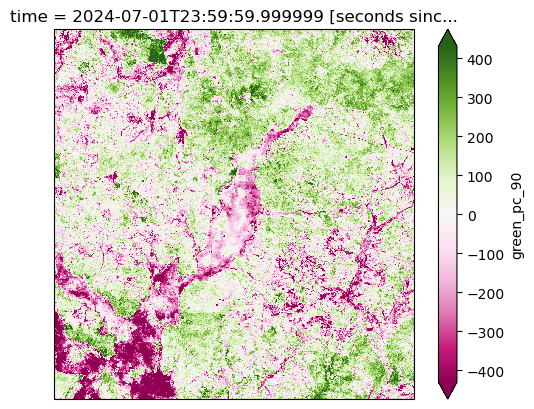

In [52]:
import matplotlib.pyplot as plt
import cartopy
f, ax =plt.subplots(subplot_kw=dict(projection=cartopy.crs.epsg(3577)))
data = ds.diff('time').green_pc_90[0].astype(float)
data.plot(ax=ax, cmap='PiYG',
               vmin=-np.max([np.abs(data.min()), data.max()]) * 0.2,
               vmax=np.max([np.abs(data.min()), data.max()]) * 0.2)
# im = ax.imshow(data, cmap='PiYG',
#                vmin=-np.max([np.abs(data.min()), data.max()]) * 0.2,
#                vmax=np.max([np.abs(data.min()), data.max()]) * 0.2)